# 15 - Introduction to PyTorch for Tabular Deep Learning

This notebook extends EnergyTypeNet from the custom NumPy MLP in Notebook 14 into PyTorch. The goal is to show the same neural-network ideas with tensors, autograd, `nn.Module`, `Dataset` / `DataLoader`, optimizers, schedulers, regularization, saving/loading, hyperparameter tuning and evaluation.

EnergyTypeNet is the primary dataset. Small synthetic data is used only when it makes tensor and autograd mechanics easier to see.


## 0. Requirements and Setup


In [2]:
import importlib
import importlib.util
import os
import random
import sys
import time
from pathlib import Path

for pkg in ['torch', 'torchvision']:
    if importlib.util.find_spec(pkg) is None:
        print(f'[WARNING] {pkg} not installed. Run: pip install {pkg}')

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import DataLoader, Dataset
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError('Notebook 15 requires PyTorch. Run: pip install torch torchvision') from exc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_regression
from sklearn.metrics import (
    accuracy_score, auc, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, mean_absolute_error, mean_squared_error,
    precision_score, recall_score, r2_score, roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import label_binarize, StandardScaler

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.data import CLASSES, load_features, load_raw
from src.models import MLPCustom

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

DATA_DIR = PROJECT_ROOT / 'data'
MODEL_DIR = PROJECT_ROOT / 'models'
MODEL_DIR.mkdir(exist_ok=True)


PyTorch version: 2.12.1+cpu
CUDA available: False
Using device: cpu


**Observation:** This run used the CPU build of PyTorch. That is appropriate for this project because EnergyTypeNet is a small tabular dataset; GPU acceleration would matter more for larger neural networks, image models or transformer-style experiments.


## 1. PyTorch Tensors


In [3]:
list_tensor = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float32)
np_array = np.array([[1.0, 2.0], [3.0, 4.0]], dtype=np.float32)
shared_tensor = torch.from_numpy(np_array)

examples = {
    'from_list': list_tensor,
    'from_numpy_shared': shared_tensor,
    'zeros': torch.zeros((2, 3)),
    'ones': torch.ones((2, 3)),
    'rand': torch.rand((2, 3)),
    'randn': torch.randn((2, 3)),
    'arange': torch.arange(0, 6).reshape(2, 3),
    'bool': torch.tensor([True, False]),
    'int64': torch.tensor([1, 2, 3], dtype=torch.int64),
}

for name, tensor in examples.items():
    print(f'{name:18s} shape={tuple(tensor.shape)} dtype={tensor.dtype} device={tensor.device}')

np_array[0, 0] = 99.0
print('Shared memory value after NumPy edit:', shared_tensor[0, 0].item())
print('Moved to selected device:', list_tensor.to(DEVICE).device)


from_list          shape=(2, 3) dtype=torch.float32 device=cpu
from_numpy_shared  shape=(2, 2) dtype=torch.float32 device=cpu
zeros              shape=(2, 3) dtype=torch.float32 device=cpu
ones               shape=(2, 3) dtype=torch.float32 device=cpu
rand               shape=(2, 3) dtype=torch.float32 device=cpu
randn              shape=(2, 3) dtype=torch.float32 device=cpu
arange             shape=(2, 3) dtype=torch.int64 device=cpu
bool               shape=(2,) dtype=torch.bool device=cpu
int64              shape=(3,) dtype=torch.int64 device=cpu
Shared memory value after NumPy edit: 99.0
Moved to selected device: cpu


**Observation:** The NumPy-backed tensor changed when the original array was edited, confirming that `torch.from_numpy` shares memory. This is useful for efficiency, but it also means mutation can silently affect downstream tensors.


In [4]:
X_demo_np, y_demo_np = make_regression(n_samples=32, n_features=10, noise=5.0, random_state=RANDOM_STATE)
X_demo = torch.tensor(X_demo_np, dtype=torch.float32)
y_demo = torch.tensor(y_demo_np, dtype=torch.float32).view(-1, 1)

print('Arithmetic:', (X_demo[:2, :3] + 2).shape)
print('Matrix multiply:', (X_demo @ torch.randn(10, 1)).shape)
print('torch.mm:', torch.mm(X_demo[:4], torch.randn(10, 3)).shape)
print('torch.bmm:', torch.bmm(torch.randn(4, 2, 3), torch.randn(4, 3, 5)).shape)
print('reshape/view:', X_demo.reshape(4, 8, 10).shape, X_demo.view(4, 8, 10).shape)
print('squeeze/unsqueeze:', y_demo.squeeze().shape, y_demo.squeeze().unsqueeze(1).shape)
print('transpose:', X_demo.T.shape)
print('reductions:', X_demo.mean().item(), X_demo.std().item(), X_demo.argmax(dim=1)[:5])
print('broadcast:', (torch.ones(32, 1) + torch.arange(10).view(1, 10)).shape)
print('boolean mask:', X_demo[y_demo.squeeze() > y_demo.mean()].shape)

z = torch.ones(3)
z.add_(2)
print('In-place add_ result:', z)


Arithmetic: torch.Size([2, 3])
Matrix multiply: torch.Size([32, 1])
torch.mm: torch.Size([4, 3])
torch.bmm: torch.Size([4, 2, 5])
reshape/view: torch.Size([4, 8, 10]) torch.Size([4, 8, 10])
squeeze/unsqueeze: torch.Size([32]) torch.Size([32, 1])
transpose: torch.Size([10, 32])
reductions: 0.01201111450791359 0.9678860306739807 tensor([2, 6, 4, 3, 7])
broadcast: torch.Size([32, 10])
boolean mask: torch.Size([16, 10])
In-place add_ result: tensor([3., 3., 3.])


In [5]:
t = torch.randn(3, 3)
print('to DEVICE:', t.to(DEVICE).device)

if torch.cuda.is_available():
    try:
        cpu_tensor = torch.ones(2, 2)
        gpu_tensor = torch.ones(2, 2, device='cuda')
        _ = cpu_tensor + gpu_tensor
    except RuntimeError as exc:
        print('Caught mixed-device error:', str(exc).split('\n')[0])
        fixed = cpu_tensor.to('cuda') + gpu_tensor
        print('Fixed device:', fixed.device)
else:
    print('CUDA unavailable: mixed-device CUDA demo skipped.')


to DEVICE: cpu
CUDA unavailable: mixed-device CUDA demo skipped.


**Observation:** `torch.from_numpy` shares memory with the original NumPy array. This is efficient, but accidental mutation of the NumPy array can change the tensor.


## 2. Autograd and Computational Graphs


In [6]:
X_scalar = torch.linspace(-2, 2, 10).view(-1, 1)
y_scalar = 3 * X_scalar.squeeze() + 2
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

y_pred = X_scalar.squeeze() * w + b
loss = ((y_pred - y_scalar) ** 2).mean()
loss.backward()

manual_dw = (2 * X_scalar.squeeze() * (y_pred.detach() - y_scalar)).mean()
manual_db = (2 * (y_pred.detach() - y_scalar)).mean()

print('loss:', float(loss.detach()))
print('w.grad:', float(w.grad), 'manual:', float(manual_dw))
print('b.grad:', float(b.grad), 'manual:', float(manual_db))


loss: 28.640411376953125
w.grad: -12.032133102416992 manual: -12.032135963439941
b.grad: -5.071894645690918 manual: -5.071894645690918


**Observation:** The autograd gradients match the hand-derived gradients up to floating-point precision. This verifies that PyTorch is building the expected computational graph for the scalar regression example.


In [7]:
w2 = torch.tensor([1.0], requires_grad=True)
(w2 ** 2).sum().backward()
print('After first backward:', w2.grad.item())
(3 * w2 ** 2).sum().backward()
print('After second backward without zeroing:', w2.grad.item())
w2.grad.zero_()
(3 * w2 ** 2).sum().backward()
print('After zeroing:', w2.grad.item())

w2.grad.zero_()
for _ in range(4):
    ((w2 ** 2).sum() / 4).backward()
print('Accumulated average gradient:', w2.grad.item())


After first backward: 2.0
After second backward without zeroing: 8.0
After zeroing: 6.0
Accumulated average gradient: 2.0


In [8]:
class CustomReLU(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input_tensor):
        ctx.save_for_backward(input_tensor)
        return torch.clamp(input_tensor, min=0)

    @staticmethod
    def backward(ctx, grad_output):
        (input_tensor,) = ctx.saved_tensors
        grad_input = grad_output.clone()
        grad_input[input_tensor <= 0] = 0
        return grad_input

x_check = torch.randn(5, dtype=torch.double, requires_grad=True)
print('Matches torch.relu:', torch.allclose(CustomReLU.apply(x_check), torch.relu(x_check)))
print('Gradcheck:', torch.autograd.gradcheck(CustomReLU.apply, (x_check,), eps=1e-6, atol=1e-4))


Matches torch.relu: True
Gradcheck: True


**Observation:** The custom ReLU passes `gradcheck`, so its backward implementation is consistent with numerical finite-difference gradients.


**Observation:** Autograd matches the manual derivative in the scalar regression example. Gradients accumulate by default, so training loops must call `optimizer.zero_grad()` before each update unless intentional micro-batch accumulation is being used.


## 3. `nn.Module`, EnergyNet and Activations


In [9]:
class EnergyNet(nn.Module):
    def __init__(self, input_dim, hidden_dims, n_classes, dropout_rate=0.0, use_batch_norm=False):
        super().__init__()
        layers = []
        prev = input_dim
        for hidden in hidden_dims:
            layers.append(nn.Linear(prev, hidden))
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(hidden))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            prev = hidden
        layers.append(nn.Linear(prev, n_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

    def summary(self):
        rows = []
        for name, module in self.named_modules():
            if name and len(list(module.children())) == 0:
                rows.append({
                    'layer': name,
                    'type': module.__class__.__name__,
                    'params': sum(p.numel() for p in module.parameters()),
                })
        return pd.DataFrame(rows)


class RegressionNet(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout_rate=0.0, use_batch_norm=False):
        super().__init__()
        self.base = EnergyNet(input_dim, hidden_dims, 1, dropout_rate, use_batch_norm)

    def forward(self, x):
        return self.base(x).squeeze(-1)


seq_model = nn.Sequential(nn.Linear(4, 6), nn.ReLU(), nn.Linear(6, 3))
sub_model = EnergyNet(4, [6], 3)
with torch.no_grad():
    sub_model.network[0].weight.copy_(seq_model[0].weight)
    sub_model.network[0].bias.copy_(seq_model[0].bias)
    sub_model.network[2].weight.copy_(seq_model[2].weight)
    sub_model.network[2].bias.copy_(seq_model[2].bias)

x_same = torch.randn(5, 4)
print('Sequential and subclass outputs identical:', torch.allclose(seq_model(x_same), sub_model(x_same)))
print('Total params:', sum(p.numel() for p in sub_model.parameters()))
display(EnergyNet(5, [64, 32], 3, dropout_rate=0.2, use_batch_norm=True).summary())


Sequential and subclass outputs identical: True
Total params: 51


,layer,type,params
0,network.0,Linear,384
1,network.1,BatchNorm1d,128
2,network.2,ReLU,0
3,network.3,Dropout,0
4,network.4,Linear,2080
5,network.5,BatchNorm1d,64
6,network.6,ReLU,0
7,network.7,Dropout,0
8,network.8,Linear,99


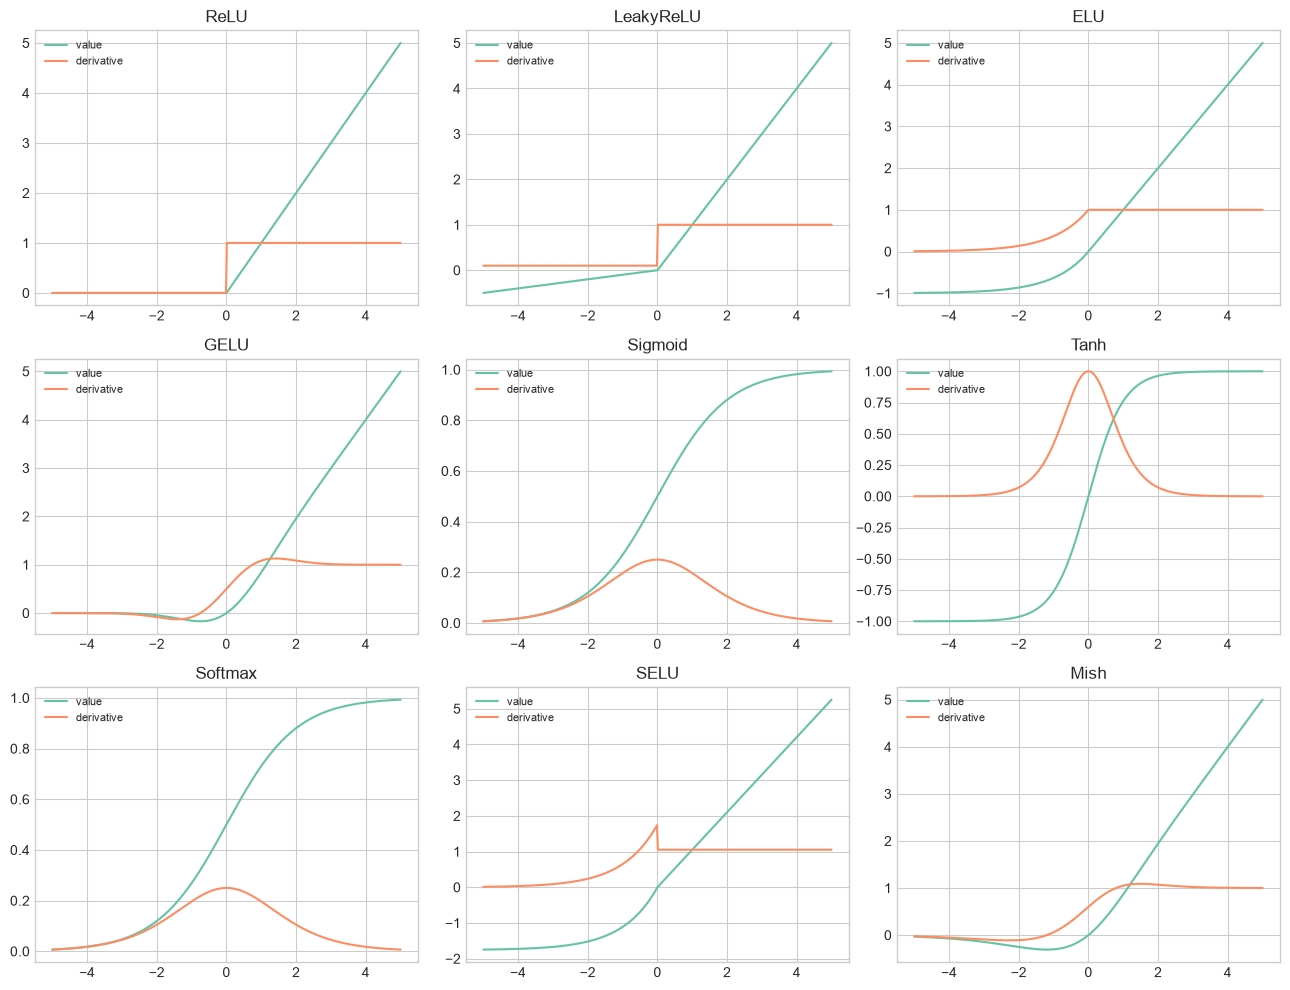

,activation,when_to_use
0,ReLU,default hidden baseline
1,LeakyReLU / ELU,reduce dying-ReLU risk
2,GELU / Mish,smooth modern activations
3,Sigmoid / Tanh,bounded but saturation-prone
4,Softmax,multiclass probability output


In [11]:
z = torch.linspace(-5, 5, 400).view(-1, 1)
activations = {
    'ReLU': nn.ReLU(),
    'LeakyReLU': nn.LeakyReLU(0.1),
    'ELU': nn.ELU(),
    'GELU': nn.GELU(),
    'Sigmoid': nn.Sigmoid(),
    'Tanh': nn.Tanh(),
    'Softmax': nn.Softmax(dim=1),
    'SELU': nn.SELU(),
    'Mish': nn.Mish(),
}

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, (name, act) in zip(axes.ravel(), activations.items()):
    x = z.clone().detach().requires_grad_(True)
    y = act(torch.cat([x, torch.zeros_like(x)], dim=1))[:, 0] if name == 'Softmax' else act(x).squeeze()
    grad = torch.autograd.grad(y.sum(), x)[0].detach().numpy().ravel()
    ax.plot(z.numpy(), y.detach().numpy(), label='value')
    ax.plot(z.numpy(), grad, label='derivative')
    ax.set_title(name)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

display(pd.DataFrame([
    ['ReLU', 'default hidden baseline'],
    ['LeakyReLU / ELU', 'reduce dying-ReLU risk'],
    ['GELU / Mish', 'smooth modern activations'],
    ['Sigmoid / Tanh', 'bounded but saturation-prone'],
    ['Softmax', 'multiclass probability output'],
], columns=['activation', 'when_to_use']))


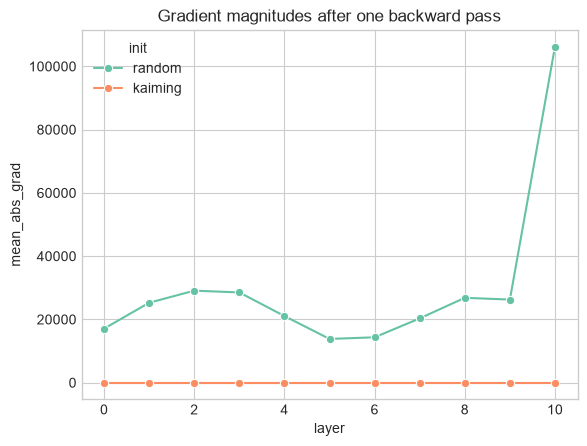

In [12]:
def init_model(model, method):
    for module in model.modules():
        if isinstance(module, nn.Linear):
            if method == 'random':
                nn.init.normal_(module.weight, mean=0.0, std=1.0)
            elif method == 'kaiming':
                nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
            elif method == 'xavier':
                nn.init.xavier_uniform_(module.weight)
            elif method == 'orthogonal':
                nn.init.orthogonal_(module.weight)
            nn.init.zeros_(module.bias)


class DeepNet(nn.Module):
    def __init__(self, input_dim=20, width=32, depth=10):
        super().__init__()
        layers = []
        prev = input_dim
        for _ in range(depth):
            layers.extend([nn.Linear(prev, width), nn.ReLU()])
            prev = width
        layers.append(nn.Linear(prev, 3))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


x_grad = torch.randn(128, 20)
y_grad = torch.randint(0, 3, (128,))
grad_rows = []
for method in ['random', 'kaiming']:
    model = DeepNet()
    init_model(model, method)
    nn.CrossEntropyLoss()(model(x_grad), y_grad).backward()
    for idx, module in enumerate([m for m in model.modules() if isinstance(m, nn.Linear)]):
        grad_rows.append({'init': method, 'layer': idx, 'mean_abs_grad': module.weight.grad.abs().mean().item()})

grad_df = pd.DataFrame(grad_rows)
sns.lineplot(data=grad_df, x='layer', y='mean_abs_grad', hue='init', marker='o')
plt.title('Gradient magnitudes after one backward pass')
plt.show()


**Observation:** `nn.Module` supplies reusable model structure, parameter discovery, `state_dict` serialization and train/eval modes. Initialization changes gradient flow before learning even starts.


## 4. Loss Functions


CrossEntropyLoss: 0.5109312534332275
NLLLoss(log_softmax): 0.5109312534332275
Equal: True
BCEWithLogitsLoss: 0.3781014084815979
BCELoss(sigmoid): 0.3781014084815979
Weighted CE: 0.6159834861755371


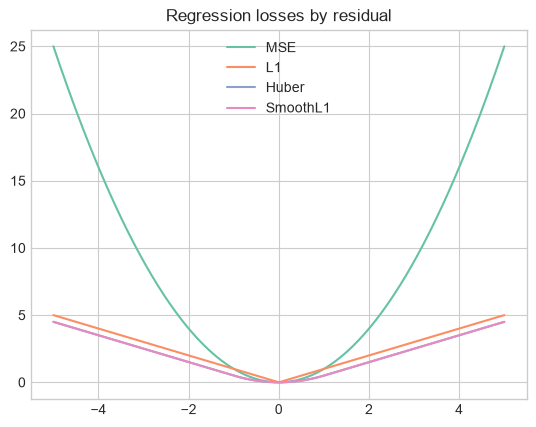

In [13]:
logits = torch.tensor([[2.0, 0.2, -1.0], [0.1, 1.2, 0.3], [0.0, -0.5, 2.0], [1.0, 1.0, 1.0]])
y_cls = torch.tensor([0, 1, 2, 1])
ce = nn.CrossEntropyLoss()(logits, y_cls)
nll = nn.NLLLoss()(F.log_softmax(logits, dim=1), y_cls)
print('CrossEntropyLoss:', ce.item())
print('NLLLoss(log_softmax):', nll.item())
print('Equal:', torch.allclose(ce, nll))

binary_logits = torch.tensor([2.0, -1.0, 0.5, -0.2])
y_bin = torch.tensor([1.0, 0.0, 1.0, 0.0])
print('BCEWithLogitsLoss:', nn.BCEWithLogitsLoss()(binary_logits, y_bin).item())
print('BCELoss(sigmoid):', nn.BCELoss()(torch.sigmoid(binary_logits), y_bin).item())
print('Weighted CE:', nn.CrossEntropyLoss(weight=torch.tensor([1.0, 2.0, 1.0]))(logits, y_cls).item())

residual = torch.linspace(-5, 5, 300)
zero = torch.zeros_like(residual)
for name, values in {
    'MSE': F.mse_loss(residual, zero, reduction='none'),
    'L1': F.l1_loss(residual, zero, reduction='none'),
    'Huber': nn.HuberLoss(delta=1.0, reduction='none')(residual, zero),
    'SmoothL1': nn.SmoothL1Loss(beta=1.0, reduction='none')(residual, zero),
}.items():
    plt.plot(residual.numpy(), values.numpy(), label=name)
plt.title('Regression losses by residual')
plt.legend()
plt.show()


**Observation:** `CrossEntropyLoss` expects raw logits and internally applies log-softmax. Huber-style losses are robust regression alternatives when large residuals should not dominate as strongly as MSE.


## 5. Dataset, DataLoader and Training Helpers


In [14]:
X_all, y_all = load_features(DATA_DIR / 'train_energy_data.csv', 'all')
X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=RANDOM_STATE)
X_test_np, y_test_np = load_features(DATA_DIR / 'test_energy_data.csv', 'all')

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_np)
X_val_sc = scaler.transform(X_val_np)
X_test_sc = scaler.transform(X_test_np)


class AddGaussianNoise:
    def __init__(self, std=0.05):
        self.std = std

    def __call__(self, x):
        return x + torch.randn_like(x) * self.std


class EnergyDataset(Dataset):
    def __init__(self, X, y, task='classification', transform=None, device=DEVICE):
        self.X = torch.tensor(X, dtype=torch.float32, device=device)
        dtype = torch.long if task == 'classification' else torch.float32
        self.y = torch.tensor(y, dtype=dtype, device=device)
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.transform is not None:
            x = self.transform(x)
        return x, self.y[idx]


train_loader = DataLoader(EnergyDataset(X_train_sc, y_train_np), batch_size=32, shuffle=True, num_workers=0)
train_aug_loader = DataLoader(EnergyDataset(X_train_sc, y_train_np, transform=AddGaussianNoise(0.03)), batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(EnergyDataset(X_val_sc, y_val_np), batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(EnergyDataset(X_test_sc, y_test_np), batch_size=64, shuffle=False, num_workers=0)

xb, yb = next(iter(train_loader))
print('Batch X shape:', xb.shape)
print('Batch y shape:', yb.shape)
print('Drop-last batch count:', len(DataLoader(EnergyDataset(X_train_sc, y_train_np), batch_size=128, drop_last=True)))

def pad_collate(batch):
    lengths = torch.tensor([len(item) for item in batch])
    return nn.utils.rnn.pad_sequence(batch, batch_first=True), lengths

print('Custom collate shapes:', [x.shape for x in pad_collate([torch.arange(n, dtype=torch.float32) for n in [3, 5, 2]])])


Batch X shape: torch.Size([32, 5])
Batch y shape: torch.Size([32])
Drop-last batch count: 6
Custom collate shapes: [torch.Size([3, 5]), torch.Size([3])]


In [15]:
def loader_accuracy(model, loader, device=DEVICE):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb.to(device))
            preds.extend(torch.argmax(logits, dim=1).detach().cpu().numpy())
            targets.extend(yb.detach().cpu().numpy())
    return accuracy_score(targets, preds)


def loader_loss(model, loader, criterion, device=DEVICE):
    model.eval()
    total_loss, total_n = 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            loss = criterion(model(xb.to(device)), yb.to(device))
            total_loss += loss.item() * len(xb)
            total_n += len(xb)
    return total_loss / max(total_n, 1)


def train_model(model, train_loader, val_loader, optimizer, scheduler=None, criterion=None, n_epochs=40, patience=10, device=DEVICE, verbose=False):
    criterion = criterion or nn.CrossEntropyLoss()
    model.to(device)
    history = {'train_losses': [], 'val_losses': [], 'train_accs': [], 'val_accs': [], 'lrs': []}
    best_state, best_val_loss, best_epoch, wait = None, np.inf, 0, 0

    for epoch in range(n_epochs):
        model.train()
        total_loss, total_n = 0.0, 0
        train_preds, train_targets = [], []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            total_loss += loss.item() * len(xb)
            total_n += len(xb)
            train_preds.extend(torch.argmax(logits.detach(), dim=1).cpu().numpy())
            train_targets.extend(yb.detach().cpu().numpy())

        train_loss = total_loss / max(total_n, 1)
        val_loss = loader_loss(model, val_loader, criterion, device)
        train_acc = accuracy_score(train_targets, train_preds)
        val_acc = loader_accuracy(model, val_loader, device)
        lr = optimizer.param_groups[0]['lr']
        history['train_losses'].append(train_loss)
        history['val_losses'].append(val_loss)
        history['train_accs'].append(train_acc)
        history['val_accs'].append(val_acc)
        history['lrs'].append(lr)

        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        if val_loss < best_val_loss - 1e-8:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    history['best_epoch'] = best_epoch
    history['best_val_acc'] = max(history['val_accs']) if history['val_accs'] else None
    return history


batch_model = EnergyNet(X_train_sc.shape[1], [32], len(CLASSES)).to(DEVICE)
loss = nn.CrossEntropyLoss()(batch_model(xb), yb)
loss.backward()
print('One-batch CE loss:', loss.item())
for name, param in batch_model.named_parameters():
    if param.grad is not None:
        print(f'{name:30s} grad_norm={param.grad.norm().item():.6f}')


One-batch CE loss: 1.1179687976837158
network.0.weight               grad_norm=0.155090
network.0.bias                 grad_norm=0.057371
network.2.weight               grad_norm=0.396353
network.2.bias                 grad_norm=0.137001


**Observation:** The first batch produces finite loss and nonzero gradients in both layers. This is a useful low-level sanity check before running full training loops.


**Observation:** `Dataset` controls row access and optional transforms; `DataLoader` controls batching, shuffling and epoch iteration. The training loop mirrors the same logic as the NumPy MLP, but autograd computes the gradients.


## 6. Optimizers, Learning Rates and Gradient Clipping


,optimizer,final_train_loss,val_acc,test_acc
1,SGD Nesterov,0.020834,1.00,1.00
2,RMSprop,0.018759,1.00,1.00
4,AdamW,0.028416,1.00,1.00
3,Adam,0.027876,1.00,1.00
5,Adagrad,0.074448,1.00,1.00
0,SGD,1.014941,0.51,0.51


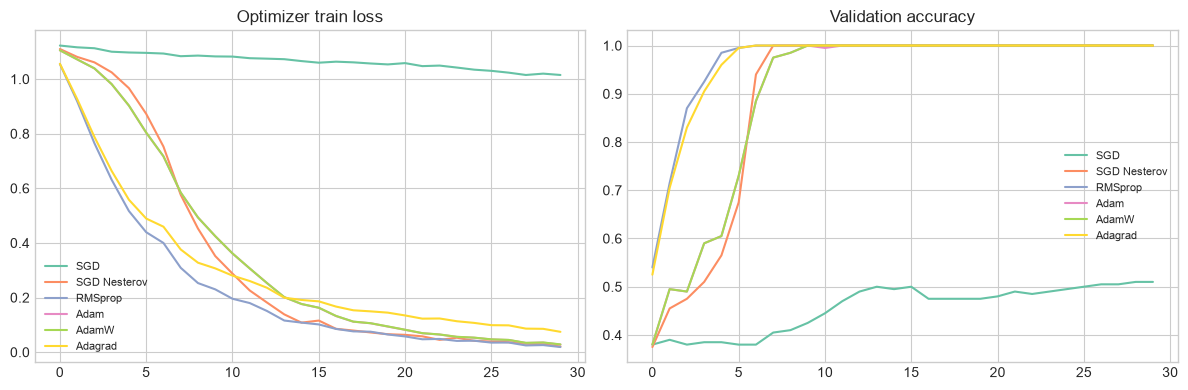

In [16]:
optimizer_specs = [
    ('SGD', lambda p: torch.optim.SGD(p, lr=0.01)),
    ('SGD Nesterov', lambda p: torch.optim.SGD(p, lr=0.01, momentum=0.9, nesterov=True)),
    ('RMSprop', lambda p: torch.optim.RMSprop(p, lr=0.001, alpha=0.99)),
    ('Adam', lambda p: torch.optim.Adam(p, lr=0.001)),
    ('AdamW', lambda p: torch.optim.AdamW(p, lr=0.001, weight_decay=0.01)),
    ('Adagrad', lambda p: torch.optim.Adagrad(p, lr=0.01)),
]

opt_rows, opt_histories = [], {}
for name, make_opt in optimizer_specs:
    torch.manual_seed(RANDOM_STATE)
    model = EnergyNet(X_train_sc.shape[1], [64, 32], len(CLASSES), dropout_rate=0.2).to(DEVICE)
    hist = train_model(model, train_loader, val_loader, make_opt(model.parameters()), n_epochs=30, patience=8)
    opt_histories[name] = hist
    opt_rows.append({'optimizer': name, 'final_train_loss': hist['train_losses'][-1], 'val_acc': hist['val_accs'][-1], 'test_acc': loader_accuracy(model, test_loader)})

display(pd.DataFrame(opt_rows).sort_values('test_acc', ascending=False))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, hist in opt_histories.items():
    axes[0].plot(hist['train_losses'], label=name)
    axes[1].plot(hist['val_accs'], label=name)
axes[0].set_title('Optimizer train loss')
axes[1].set_title('Validation accuracy')
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


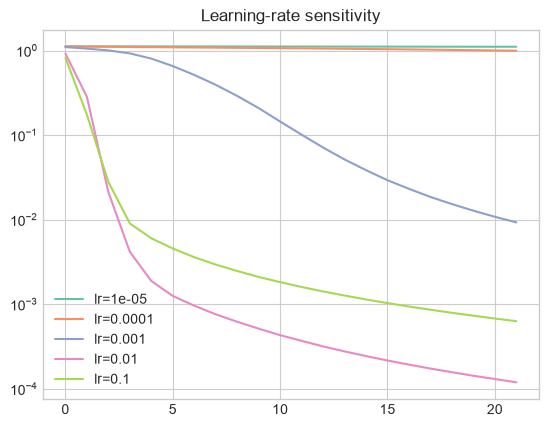

,lr,final_val_loss,val_acc
0,0.00001,1.107160,0.390
1,0.00010,0.983285,0.525
2,0.00100,0.009232,1.000
3,0.01000,0.000128,1.000
4,0.10000,0.000605,1.000


In [17]:
lr_rows, lr_histories = [], {}
for lr in [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]:
    torch.manual_seed(RANDOM_STATE)
    model = EnergyNet(X_train_sc.shape[1], [64, 32], len(CLASSES)).to(DEVICE)
    hist = train_model(model, train_loader, val_loader, torch.optim.Adam(model.parameters(), lr=lr), n_epochs=22, patience=6)
    lr_histories[lr] = hist
    lr_rows.append({'lr': lr, 'final_val_loss': hist['val_losses'][-1], 'val_acc': hist['val_accs'][-1]})

for lr, hist in lr_histories.items():
    plt.plot(hist['train_losses'], label=f'lr={lr:g}')
plt.yscale('log')
plt.title('Learning-rate sensitivity')
plt.legend()
plt.show()
display(pd.DataFrame(lr_rows))


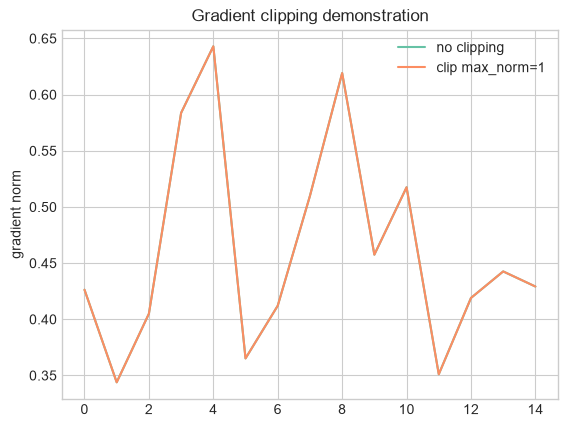

In [18]:
def run_high_lr_clip(use_clip):
    torch.manual_seed(RANDOM_STATE)
    model = EnergyNet(X_train_sc.shape[1], [128, 64], len(CLASSES)).to(DEVICE)
    opt = torch.optim.SGD(model.parameters(), lr=0.1)
    criterion = nn.CrossEntropyLoss()
    norms = []
    for _ in range(15):
        model.train()
        xb_i, yb_i = next(iter(train_loader))
        opt.zero_grad()
        loss = criterion(model(xb_i), yb_i)
        loss.backward()
        total_norm = torch.sqrt(sum((p.grad.norm() ** 2) for p in model.parameters() if p.grad is not None))
        norms.append(total_norm.item())
        if use_clip:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
    return norms

plt.plot(run_high_lr_clip(False), label='no clipping')
plt.plot(run_high_lr_clip(True), label='clip max_norm=1')
plt.title('Gradient clipping demonstration')
plt.ylabel('gradient norm')
plt.legend()
plt.show()


**Observation:** PyTorch optimizers share the same interface, making optimizer studies much cleaner than writing each update rule manually. Gradient clipping is a useful stabilizer when gradients grow too large.


## 7. Learning-Rate Schedulers


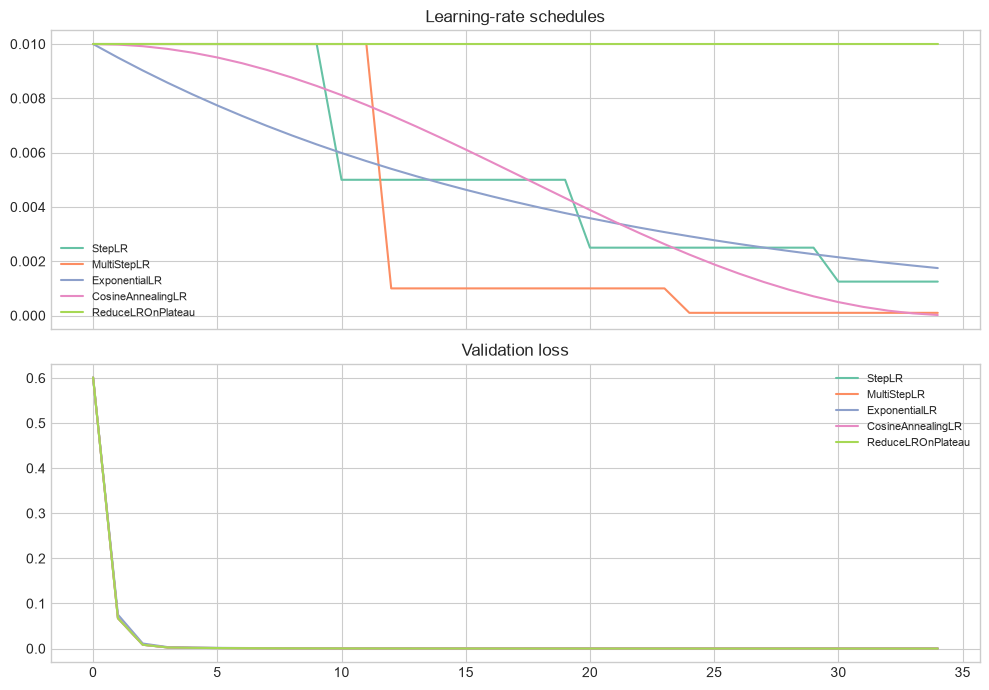

,scheduler,final_lr,final_val_loss,test_acc
0,StepLR,0.001250,0.000161,1.0
1,MultiStepLR,0.000100,0.000303,1.0
2,ExponentialLR,0.001748,0.000171,1.0
3,CosineAnnealingLR,0.000020,0.000170,1.0
4,ReduceLROnPlateau,0.010000,0.000054,1.0


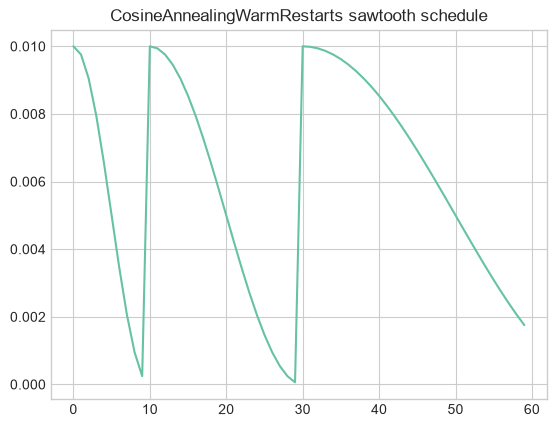

In [19]:
sched_names = ['StepLR', 'MultiStepLR', 'ExponentialLR', 'CosineAnnealingLR', 'ReduceLROnPlateau']
sched_histories, sched_rows = {}, []
for name in sched_names:
    torch.manual_seed(RANDOM_STATE)
    model = EnergyNet(X_train_sc.shape[1], [64, 32], len(CLASSES)).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    if name == 'StepLR':
        sched = torch.optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.5)
    elif name == 'MultiStepLR':
        sched = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[12, 24], gamma=0.1)
    elif name == 'ExponentialLR':
        sched = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.95)
    elif name == 'CosineAnnealingLR':
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=35)
    else:
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', patience=5, factor=0.5)
    hist = train_model(model, train_loader, val_loader, opt, scheduler=sched, n_epochs=35, patience=10)
    sched_histories[name] = hist
    sched_rows.append({'scheduler': name, 'final_lr': hist['lrs'][-1], 'final_val_loss': hist['val_losses'][-1], 'test_acc': loader_accuracy(model, test_loader)})

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
for name, hist in sched_histories.items():
    axes[0].plot(hist['lrs'], label=name)
    axes[1].plot(hist['val_losses'], label=name)
axes[0].set_title('Learning-rate schedules')
axes[1].set_title('Validation loss')
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
display(pd.DataFrame(sched_rows))

model = EnergyNet(X_train_sc.shape[1], [32], len(CLASSES)).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=0.01)
warm = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=10, T_mult=2)
lrs = []
for _ in range(60):
    lrs.append(opt.param_groups[0]['lr'])
    warm.step()
plt.plot(lrs)
plt.title('CosineAnnealingWarmRestarts sawtooth schedule')
plt.show()


**Observation:** Schedulers control how aggressively optimization moves over time. Step schedules reduce abruptly, cosine schedules decay smoothly, and warm restarts periodically increase learning rate to encourage renewed exploration.


## 8. Regularization in PyTorch


,dropout_rate,train_acc,val_acc,gap,test_acc
0,0.0,1.00000,1.0,0.00000,1.0
1,0.2,1.00000,1.0,0.00000,1.0
2,0.4,0.99375,1.0,-0.00625,1.0
3,0.6,0.98000,1.0,-0.02000,1.0


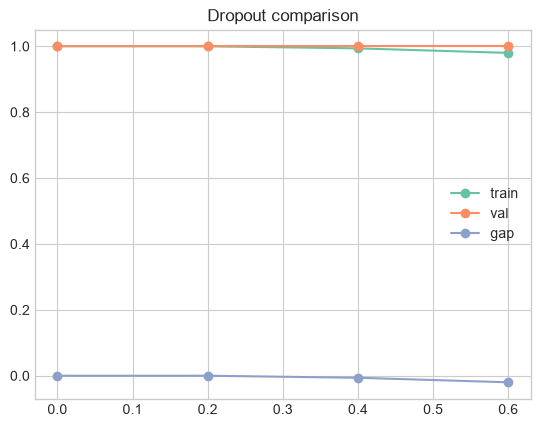

Train outputs identical? False
Eval outputs identical? True


In [20]:
drop_rows = []
for rate in [0.0, 0.2, 0.4, 0.6]:
    torch.manual_seed(RANDOM_STATE)
    model = EnergyNet(X_train_sc.shape[1], [128, 64], len(CLASSES), dropout_rate=rate).to(DEVICE)
    hist = train_model(model, train_loader, val_loader, torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4), n_epochs=35, patience=8)
    train_acc, val_acc = hist['train_accs'][-1], hist['val_accs'][-1]
    drop_rows.append({'dropout_rate': rate, 'train_acc': train_acc, 'val_acc': val_acc, 'gap': train_acc - val_acc, 'test_acc': loader_accuracy(model, test_loader)})

drop_df = pd.DataFrame(drop_rows)
display(drop_df)
plt.plot(drop_df['dropout_rate'], drop_df['train_acc'], marker='o', label='train')
plt.plot(drop_df['dropout_rate'], drop_df['val_acc'], marker='o', label='val')
plt.plot(drop_df['dropout_rate'], drop_df['gap'], marker='o', label='gap')
plt.title('Dropout comparison')
plt.legend()
plt.show()

drop_model = EnergyNet(X_train_sc.shape[1], [16], len(CLASSES), dropout_rate=0.5).to(DEVICE)
drop_model.train()
out_train_1, out_train_2 = drop_model(xb), drop_model(xb)
drop_model.eval()
out_eval_1, out_eval_2 = drop_model(xb), drop_model(xb)
print('Train outputs identical?', torch.allclose(out_train_1, out_train_2))
print('Eval outputs identical?', torch.allclose(out_eval_1, out_eval_2))


,batch_norm,final_val_loss,test_acc
0,False,0.006243,1.0
1,True,0.002789,1.0


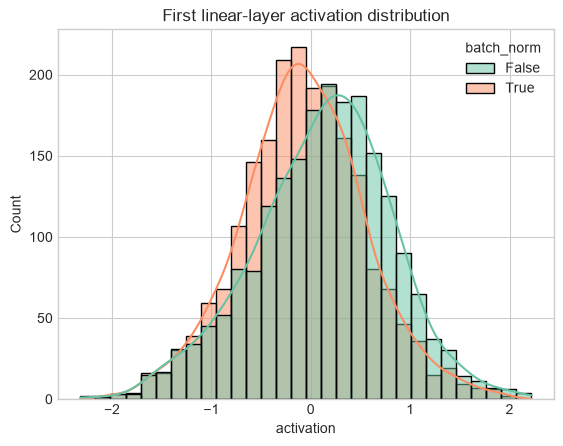

Normalization alternatives: ['LayerNorm', 'GroupNorm', 'InstanceNorm1d']


In [21]:
bn_rows, activation_records = [], []
for use_bn in [False, True]:
    torch.manual_seed(RANDOM_STATE)
    model = EnergyNet(X_train_sc.shape[1], [64, 32], len(CLASSES), use_batch_norm=use_bn).to(DEVICE)
    hist = train_model(model, train_loader, val_loader, torch.optim.Adam(model.parameters(), lr=1e-3), n_epochs=25, patience=8)
    bn_rows.append({'batch_norm': use_bn, 'final_val_loss': hist['val_losses'][-1], 'test_acc': loader_accuracy(model, test_loader)})
    first_linear = next(m for m in model.modules() if isinstance(m, nn.Linear))
    model.eval()
    with torch.no_grad():
        acts = first_linear(xb).detach().cpu().numpy().ravel()
    activation_records.append(pd.DataFrame({'activation': acts, 'batch_norm': str(use_bn)}))

display(pd.DataFrame(bn_rows))
sns.histplot(data=pd.concat(activation_records), x='activation', hue='batch_norm', bins=30, kde=True)
plt.title('First linear-layer activation distribution')
plt.show()

print('Normalization alternatives:', [nn.LayerNorm(8).__class__.__name__, nn.GroupNorm(2, 8).__class__.__name__, nn.InstanceNorm1d(8).__class__.__name__])


,regularizer,weight_sparsity_abs_lt_1e-3,test_acc
0,none,0.007305,1.0
1,l2_adamw,0.006899,1.0
2,l1_manual,0.052760,1.0


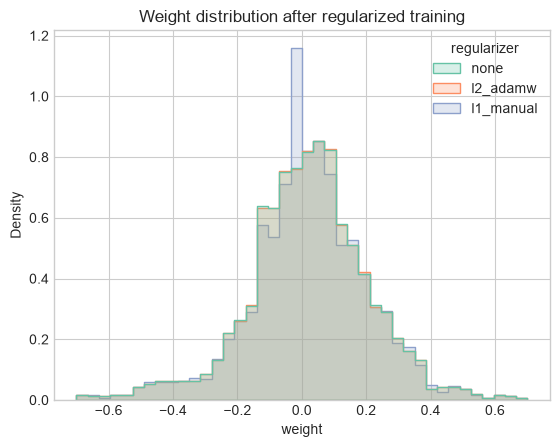

In [22]:
reg_rows, weight_records = [], []
for name, weight_decay, l1_lambda in [('none', 0.0, 0.0), ('l2_adamw', 1e-3, 0.0), ('l1_manual', 0.0, 1e-5)]:
    torch.manual_seed(RANDOM_STATE)
    model = EnergyNet(X_train_sc.shape[1], [64, 32], len(CLASSES)).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    for _ in range(20):
        model.train()
        for xb_i, yb_i in train_loader:
            opt.zero_grad()
            loss = criterion(model(xb_i), yb_i)
            if l1_lambda > 0:
                loss = loss + l1_lambda * sum(p.abs().sum() for p in model.parameters())
            loss.backward()
            opt.step()
    weights = torch.cat([p.detach().flatten().cpu() for p in model.parameters() if p.ndim > 1]).numpy()
    weight_records.append(pd.DataFrame({'weight': weights, 'regularizer': name}))
    reg_rows.append({'regularizer': name, 'weight_sparsity_abs_lt_1e-3': float(np.mean(np.abs(weights) < 1e-3)), 'test_acc': loader_accuracy(model, test_loader)})

display(pd.DataFrame(reg_rows))
sns.histplot(data=pd.concat(weight_records), x='weight', hue='regularizer', bins=40, element='step', stat='density')
plt.title('Weight distribution after regularized training')
plt.show()


**Observation:** Dropout changes behavior between `train()` and `eval()` mode. L2 is usually optimizer weight decay; L1 is usually added manually to the loss when sparse weights are desired.


## 9. Full Training Loop, Saving and Evaluation


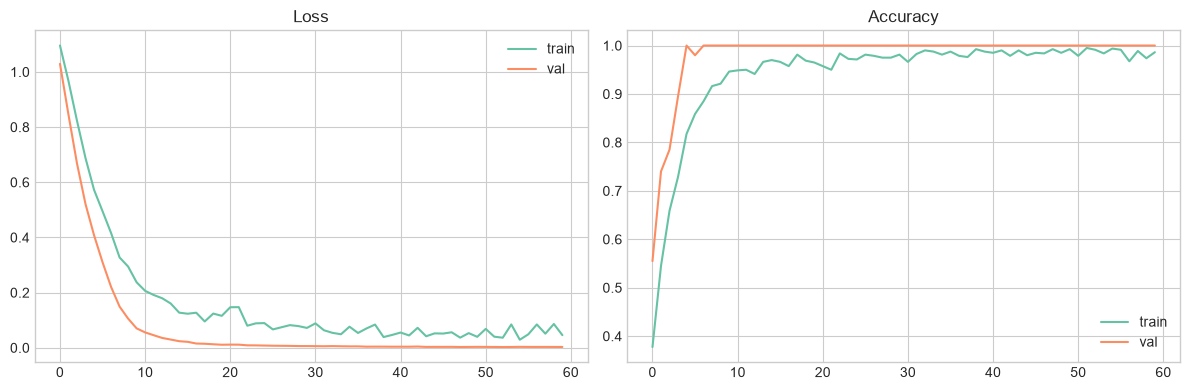

Best epoch: 53
Best validation accuracy: 1.0
Test accuracy: 1.0


In [23]:
torch.manual_seed(RANDOM_STATE)
best_model = EnergyNet(X_train_sc.shape[1], [128, 64, 32], len(CLASSES), dropout_rate=0.3, use_batch_norm=True).to(DEVICE)
optimizer = torch.optim.AdamW(best_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=60)
history = train_model(best_model, train_loader, val_loader, optimizer, scheduler=scheduler, n_epochs=60, patience=15)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_losses'], label='train')
axes[0].plot(history['val_losses'], label='val')
axes[0].set_title('Loss')
axes[1].plot(history['train_accs'], label='train')
axes[1].plot(history['val_accs'], label='val')
axes[1].set_title('Accuracy')
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

print('Best epoch:', history['best_epoch'])
print('Best validation accuracy:', history['best_val_acc'])
print('Test accuracy:', loader_accuracy(best_model, test_loader))


**Observation:** Early stopping selected a checkpoint before the maximum epoch budget, and the saved model reached perfect holdout accuracy. This confirms that the checkpointing loop is working and not simply returning the final epoch by default.


In [27]:
state_path = MODEL_DIR / 'energy_net.pt'
torch.save(best_model.state_dict(), state_path)
loaded_model = EnergyNet(X_train_sc.shape[1], [128, 64, 32], len(CLASSES), dropout_rate=0.3, use_batch_norm=True).to(DEVICE)
loaded_model.load_state_dict(torch.load(state_path, map_location=DEVICE))
loaded_model.eval()
with torch.no_grad():
    test_tensor = torch.tensor(X_test_sc, dtype=torch.float32, device=DEVICE)
    original_pred = torch.argmax(best_model(test_tensor), dim=1)
    loaded_pred = torch.argmax(loaded_model(test_tensor), dim=1)
print('Loaded predictions identical:', torch.equal(original_pred, loaded_pred))
# print('Saved state_dict:', state_path)


Loaded predictions identical: True


**Observation:** Reloading the saved `state_dict` gives identical predictions, so the PyTorch checkpoint is reproducible for inference.


,accuracy,precision_macro,recall_macro,f1_macro
0,1.0,1.0,1.0,1.0


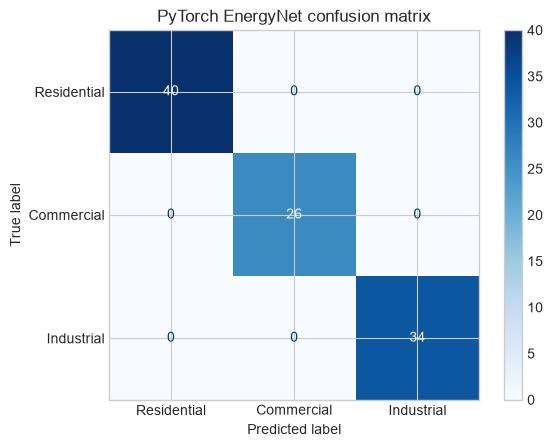

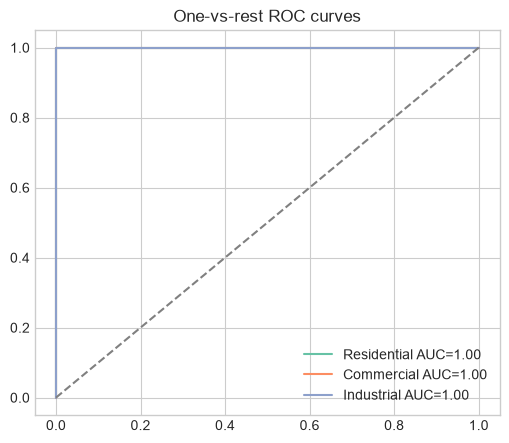

In [28]:
best_model.eval()
with torch.no_grad():
    logits = best_model(torch.tensor(X_test_sc, dtype=torch.float32, device=DEVICE))
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    y_pred = probs.argmax(axis=1)

metrics = {
    'accuracy': accuracy_score(y_test_np, y_pred),
    'precision_macro': precision_score(y_test_np, y_pred, average='macro', zero_division=0),
    'recall_macro': recall_score(y_test_np, y_pred, average='macro', zero_division=0),
    'f1_macro': f1_score(y_test_np, y_pred, average='macro', zero_division=0),
}
display(pd.DataFrame([metrics]))
ConfusionMatrixDisplay(confusion_matrix(y_test_np, y_pred), display_labels=CLASSES).plot(cmap='Blues')
plt.title('PyTorch EnergyNet confusion matrix')
plt.show()

y_bin = label_binarize(y_test_np, classes=np.arange(len(CLASSES)))
fig, ax = plt.subplots(figsize=(6, 5))
for idx, cls in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(y_bin[:, idx], probs[:, idx])
    ax.plot(fpr, tpr, label=f'{cls} AUC={auc(fpr, tpr):.2f}')
ax.plot([0, 1], [0, 1], '--', color='gray')
ax.set_title('One-vs-rest ROC curves')
ax.legend()
plt.show()


**Observation:** `state_dict` saving is preferred because it stores portable learned tensors while keeping the model definition explicit in code.


## 10. Hyperparameter Tuning and Learning Curves


In [29]:
grid_rows = []
for hidden_dims in [(64,), (128, 64), (128, 64, 32)]:
    for dropout_rate in [0.1, 0.3]:
        for lr in [1e-3, 1e-4]:
            torch.manual_seed(RANDOM_STATE)
            model = EnergyNet(X_train_sc.shape[1], list(hidden_dims), len(CLASSES), dropout_rate=dropout_rate).to(DEVICE)
            hist = train_model(model, train_loader, val_loader, torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4), n_epochs=25, patience=7)
            grid_rows.append({'hidden_dims': hidden_dims, 'dropout_rate': dropout_rate, 'lr': lr, 'best_val_acc': max(hist['val_accs']), 'test_acc': loader_accuracy(model, test_loader)})

grid_df = pd.DataFrame(grid_rows).sort_values(['best_val_acc', 'test_acc'], ascending=False)
display(grid_df)
print('Best config:', grid_df.iloc[0].to_dict())


,hidden_dims,dropout_rate,lr,best_val_acc,test_acc
0,"(64,)",0.1,0.0010,1.000,1.00
2,"(64,)",0.3,0.0010,1.000,1.00
4,"(128, 64)",0.1,0.0010,1.000,1.00
6,"(128, 64)",0.3,0.0010,1.000,1.00
8,"(128, 64, 32)",0.1,0.0010,1.000,1.00
10,"(128, 64, 32)",0.3,0.0010,1.000,1.00
9,"(128, 64, 32)",0.1,0.0001,0.960,0.94
5,"(128, 64)",0.1,0.0001,0.835,0.86
7,"(128, 64)",0.3,0.0001,0.735,0.77
11,"(128, 64, 32)",0.3,0.0001,0.660,0.70


Best config: {'hidden_dims': (64,), 'dropout_rate': 0.1, 'lr': 0.001, 'best_val_acc': 1.0, 'test_acc': 1.0}


,n_samples,train_acc,val_acc,test_acc
0,50,0.6800,0.445,0.36
1,100,0.5500,0.555,0.53
2,200,0.8100,0.875,0.94
3,400,0.9775,1.000,1.00
4,800,1.0000,1.000,1.00


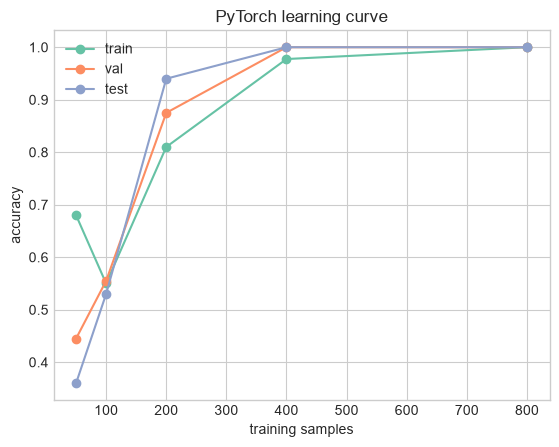

In [30]:
curve_rows = []
for n in [50, 100, 200, 400, 800]:
    idx = np.random.RandomState(RANDOM_STATE).choice(np.arange(X_train_sc.shape[0]), size=min(n, X_train_sc.shape[0]), replace=False)
    subset_loader = DataLoader(EnergyDataset(X_train_sc[idx], y_train_np[idx]), batch_size=32, shuffle=True, num_workers=0)
    torch.manual_seed(RANDOM_STATE)
    model = EnergyNet(X_train_sc.shape[1], [64, 32], len(CLASSES), dropout_rate=0.2).to(DEVICE)
    hist = train_model(model, subset_loader, val_loader, torch.optim.Adam(model.parameters(), lr=1e-3), n_epochs=30, patience=7)
    curve_rows.append({'n_samples': n, 'train_acc': hist['train_accs'][-1], 'val_acc': hist['val_accs'][-1], 'test_acc': loader_accuracy(model, test_loader)})

curve_df = pd.DataFrame(curve_rows)
display(curve_df)
plt.plot(curve_df['n_samples'], curve_df['train_acc'], marker='o', label='train')
plt.plot(curve_df['n_samples'], curve_df['val_acc'], marker='o', label='val')
plt.plot(curve_df['n_samples'], curve_df['test_acc'], marker='o', label='test')
plt.title('PyTorch learning curve')
plt.xlabel('training samples')
plt.ylabel('accuracy')
plt.legend()
plt.show()


**Observation:** Manual grid search is transparent and enough for this dataset. The learning curve checks whether adding rows helps or whether the feature representation is the limiting factor.


## 11. PyTorch vs NumPy MLP vs sklearn MLP


,model,test_accuracy,macro_f1,train_time_sec,inference_ms_per_sample
0,PyTorch EnergyNet,1.00,NaN,3.911969,0.037415
1,Custom NumPy MLPCustom,1.00,1.000000,0.987754,0.001986
2,sklearn MLPClassifier,0.99,0.988633,0.187030,0.007670


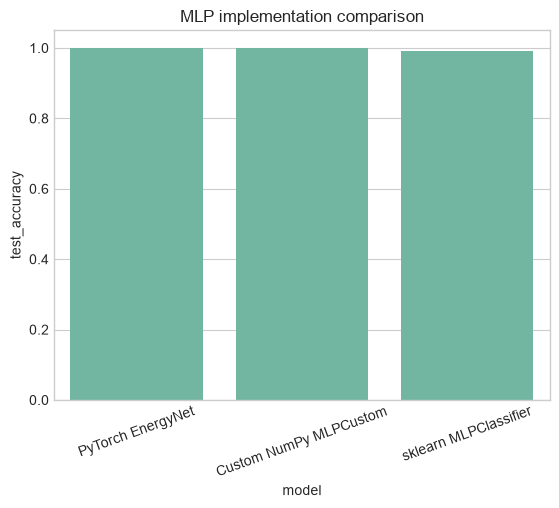

In [31]:
comparison_rows = []

start = time.perf_counter()
pt_model = EnergyNet(X_train_sc.shape[1], [64, 32], len(CLASSES), dropout_rate=0.2).to(DEVICE)
pt_hist = train_model(pt_model, train_loader, val_loader, torch.optim.Adam(pt_model.parameters(), lr=1e-3), n_epochs=40, patience=10)
train_time = time.perf_counter() - start
start_inf = time.perf_counter()
pt_preds = []
pt_true = []
pt_model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        logits = pt_model(xb)
        pt_preds.extend(logits.argmax(dim=1).cpu().numpy())
        pt_true.extend(yb.cpu().numpy())
pt_acc = accuracy_score(pt_true, pt_preds)
pt_f1 = f1_score(pt_true, pt_preds, average='macro')
inf_time = (time.perf_counter() - start_inf) / len(X_test_sc) * 1000
comparison_rows.append({'model': 'PyTorch EnergyNet', 'test_accuracy': pt_acc, 'macro_f1': pt_f1, 'train_time_sec': train_time, 'inference_ms_per_sample': inf_time})

start = time.perf_counter()
np_mlp = MLPCustom(hidden_layer_sizes=(64, 32), activation='relu', optimizer='adam', learning_rate=0.01, n_iterations=120, batch_size=32, random_state=RANDOM_STATE)
np_mlp.fit(X_train_sc, y_train_np)
train_time = time.perf_counter() - start
start_inf = time.perf_counter()
np_pred = np_mlp.predict(X_test_sc)
inf_time = (time.perf_counter() - start_inf) / len(X_test_sc) * 1000
comparison_rows.append({'model': 'Custom NumPy MLPCustom', 'test_accuracy': accuracy_score(y_test_np, np_pred), 'macro_f1': f1_score(y_test_np, np_pred, average='macro'), 'train_time_sec': train_time, 'inference_ms_per_sample': inf_time})

start = time.perf_counter()
sk_mlp = make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=400, random_state=RANDOM_STATE, early_stopping=True))
sk_mlp.fit(X_train_np, y_train_np)
train_time = time.perf_counter() - start
start_inf = time.perf_counter()
sk_pred = sk_mlp.predict(X_test_np)
inf_time = (time.perf_counter() - start_inf) / len(X_test_np) * 1000
comparison_rows.append({'model': 'sklearn MLPClassifier', 'test_accuracy': accuracy_score(y_test_np, sk_pred), 'macro_f1': f1_score(y_test_np, sk_pred, average='macro'), 'train_time_sec': train_time, 'inference_ms_per_sample': inf_time})

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)
sns.barplot(data=comparison_df, x='model', y='test_accuracy')
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.title('MLP implementation comparison')
plt.show()


**Observation:** PyTorch, the custom NumPy MLP and sklearn's MLP all perform similarly on accuracy, but sklearn trains fastest here. PyTorch is still valuable because it exposes the most control over tensors, training loops, regularization and checkpointing.


**Observation:** PyTorch is the right choice when custom architectures, GPU support, flexible training loops or differentiable components matter. sklearn remains the faster baseline tool for standard small tabular problems.


## 12. PyTorch Regression


,dataset,mse,mae,r2
0,EnergyTypeNet,177106.524164,354.252876,0.782505


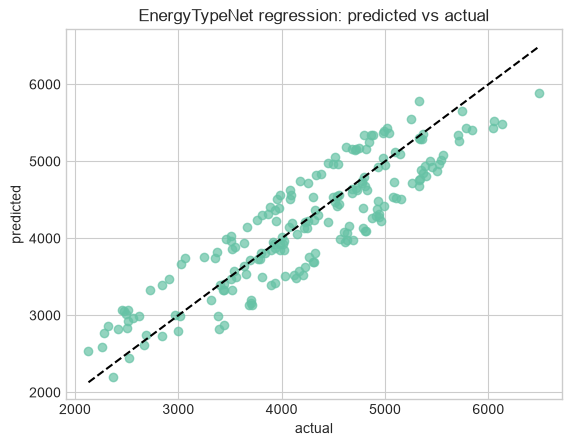

In [32]:
def train_regression_model(model, train_loader, optimizer, n_epochs=60, device=DEVICE):
    criterion = nn.MSELoss()
    model.to(device)
    losses = []
    for _ in range(n_epochs):
        model.train()
        total, total_n = 0.0, 0
        for xb_i, yb_i in train_loader:
            xb_i, yb_i = xb_i.to(device), yb_i.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb_i), yb_i)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            total += loss.item() * len(xb_i)
            total_n += len(xb_i)
        losses.append(total / max(total_n, 1))
    return losses


energy_df = load_raw(DATA_DIR / 'train_energy_data.csv')
reg_features = ['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']
X_reg = energy_df[reg_features].values.astype(float)
y_reg = energy_df['Energy Consumption'].values.astype(float)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE)
reg_scaler, y_scaler = StandardScaler(), StandardScaler()
Xr_train_sc = reg_scaler.fit_transform(Xr_train)
Xr_test_sc = reg_scaler.transform(Xr_test)
yr_train_sc = y_scaler.fit_transform(yr_train.reshape(-1, 1)).ravel()

reg_loader = DataLoader(EnergyDataset(Xr_train_sc, yr_train_sc, task='regression'), batch_size=32, shuffle=True, num_workers=0)
torch.manual_seed(RANDOM_STATE)
reg_model = RegressionNet(Xr_train_sc.shape[1], [64, 32], dropout_rate=0.1).to(DEVICE)
_ = train_regression_model(reg_model, reg_loader, torch.optim.AdamW(reg_model.parameters(), lr=1e-3, weight_decay=1e-4), n_epochs=70)
reg_model.eval()
with torch.no_grad():
    pred_sc = reg_model(torch.tensor(Xr_test_sc, dtype=torch.float32, device=DEVICE)).cpu().numpy()
y_pred_reg = y_scaler.inverse_transform(pred_sc.reshape(-1, 1)).ravel()

reg_metrics = {'dataset': 'EnergyTypeNet', 'mse': mean_squared_error(yr_test, y_pred_reg), 'mae': mean_absolute_error(yr_test, y_pred_reg), 'r2': r2_score(yr_test, y_pred_reg)}
display(pd.DataFrame([reg_metrics]))
plt.scatter(yr_test, y_pred_reg, alpha=0.7)
plt.plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], '--', color='black')
plt.xlabel('actual')
plt.ylabel('predicted')
plt.title('EnergyTypeNet regression: predicted vs actual')
plt.show()


,dataset,mse,mae,r2
0,California Housing,0.255781,0.335371,0.804808


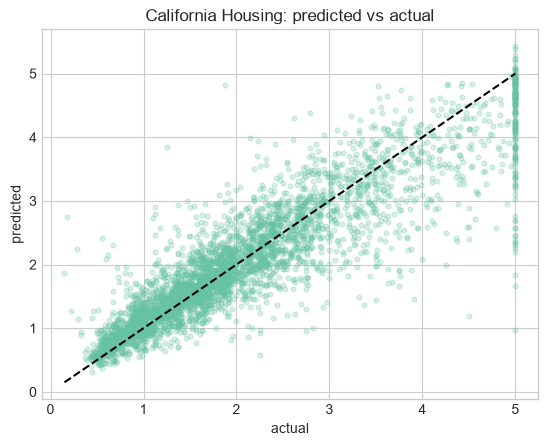

In [33]:
try:
    from sklearn.datasets import fetch_california_housing
    cal = fetch_california_housing()
    X_cal, y_cal, source = cal.data, cal.target, 'California Housing'
except Exception as exc:
    print('California Housing unavailable; using make_regression fallback:', exc)
    X_cal, y_cal = make_regression(n_samples=3000, n_features=8, noise=15.0, random_state=RANDOM_STATE)
    source = 'make_regression fallback'

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_cal, y_cal, test_size=0.2, random_state=RANDOM_STATE)
cal_scaler, yc_scaler = StandardScaler(), StandardScaler()
Xc_train_sc = cal_scaler.fit_transform(Xc_train)
Xc_test_sc = cal_scaler.transform(Xc_test)
yc_train_sc = yc_scaler.fit_transform(yc_train.reshape(-1, 1)).ravel()
cal_loader = DataLoader(EnergyDataset(Xc_train_sc, yc_train_sc, task='regression'), batch_size=64, shuffle=True, num_workers=0)
cal_model = RegressionNet(Xc_train_sc.shape[1], [128, 64], dropout_rate=0.1).to(DEVICE)
_ = train_regression_model(cal_model, cal_loader, torch.optim.AdamW(cal_model.parameters(), lr=1e-3, weight_decay=1e-4), n_epochs=60)
cal_model.eval()
with torch.no_grad():
    pred_sc = cal_model(torch.tensor(Xc_test_sc, dtype=torch.float32, device=DEVICE)).cpu().numpy()
yc_pred = yc_scaler.inverse_transform(pred_sc.reshape(-1, 1)).ravel()
cal_metrics = {'dataset': source, 'mse': mean_squared_error(yc_test, yc_pred), 'mae': mean_absolute_error(yc_test, yc_pred), 'r2': r2_score(yc_test, yc_pred)}
display(pd.DataFrame([cal_metrics]))
plt.scatter(yc_test, yc_pred, alpha=0.25, s=12)
plt.plot([yc_test.min(), yc_test.max()], [yc_test.min(), yc_test.max()], '--', color='black')
plt.xlabel('actual')
plt.ylabel('predicted')
plt.title(f'{source}: predicted vs actual')
plt.show()


**Observation:** Regression uses the same PyTorch components as classification, but changes the output head, target dtype and loss. Target scaling often makes MLP regression easier to optimize.


## 13. Summary and What's Next


In [34]:
summary = pd.DataFrame([
    {'component': 'Tensors', 'dataset': 'make_regression / examples', 'task': 'foundation', 'result': 'devices, broadcasting, indexing'},
    {'component': 'Autograd', 'dataset': 'scalar regression', 'task': 'derivatives', 'result': 'manual gradients match autograd'},
    {'component': 'EnergyNet', 'dataset': 'EnergyTypeNet', 'task': 'classification', 'result': f"test accuracy {loader_accuracy(best_model, test_loader):.3f}"},
    {'component': 'RegressionNet', 'dataset': 'EnergyTypeNet', 'task': 'regression', 'result': f"R2 {reg_metrics['r2']:.3f}"},
    {'component': 'RegressionNet', 'dataset': cal_metrics['dataset'], 'task': 'regression benchmark', 'result': f"R2 {cal_metrics['r2']:.3f}"},
])
display(summary)


,component,dataset,task,result
0,Tensors,make_regression / examples,foundation,"devices, broadcasting, indexing"
1,Autograd,scalar regression,derivatives,manual gradients match autograd
2,EnergyNet,EnergyTypeNet,classification,test accuracy 1.000
3,RegressionNet,EnergyTypeNet,regression,R2 0.783
4,RegressionNet,California Housing,regression benchmark,R2 0.805


## Final Takeaways

- PyTorch automates differentiation, but the user still controls architecture, data loading, optimization and evaluation.
- `nn.Module`, `Dataset`, `DataLoader`, optimizers and schedulers turn the NumPy MLP ideas from Notebook 14 into a framework-style workflow.
- EnergyTypeNet remains the primary dataset; synthetic examples are used only for small tensor/autograd demonstrations.
- The next branches can build on this foundation with autoencoders, CNNs and RNN/sequence models.
